**SESIÓN 1. Introducción**

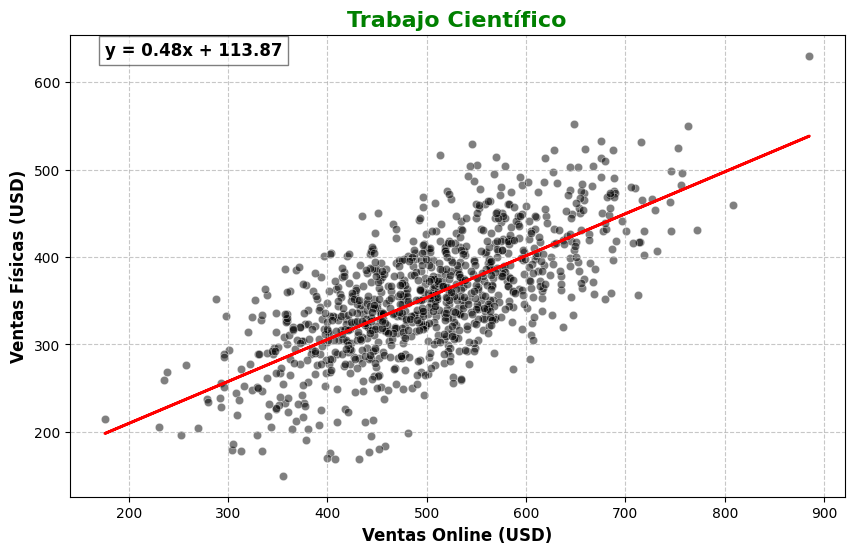

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Configuración de la simulación
np.random.seed(42)
n_registros = 1000

# Simulación de datos para la empresa TRABAJO CIENTÍFICO
ventas_online = np.random.normal(500, 100, n_registros)
ventas_fisicas = ventas_online * 0.5 + np.random.normal(100, 50, n_registros)

df = pd.DataFrame({
    'Ventas_Online': ventas_online,
    'Ventas_Fisicas': ventas_fisicas
})

# Cálculo de la línea de tendencia (regresión lineal)
X = df[['Ventas_Online']]
y = df['Ventas_Fisicas']
modelo = LinearRegression().fit(X, y)
m = modelo.coef_[0]
b = modelo.intercept_
ecuacion = f'y = {m:.2f}x + {b:.2f}'

# Elaboración de la gráfica
plt.figure(figsize=(10, 6))

# Puntos en color negro
sns.scatterplot(data=df, x='Ventas_Online', y='Ventas_Fisicas', alpha=0.5, color='black')

# Línea de tendencia en rojo
plt.plot(df['Ventas_Online'], modelo.predict(X), color='red', linewidth=2)

# Configuración de títulos y etiquetas
plt.title('Trabajo Científico', fontsize=16, fontweight='bold', color='green')
plt.xlabel('Ventas Online (USD)', fontsize=12, fontweight='bold')
plt.ylabel('Ventas Físicas (USD)', fontsize=12, fontweight='bold')

# Agregar ecuación de la recta
plt.text(df['Ventas_Online'].min(), df['Ventas_Fisicas'].max(), ecuacion,
         fontsize=12, fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
import pandas as pd

datos = pd.read_excel("/content/datos_sesion_1.xlsx")

datos.head(3)

,ID_Estudiante,Sexo,Edad,Nivel_Socioeconomico,Programa,Modalidad,Anios_Experiencia_Docente,Ingreso_Mensual_MilesCOP,Horas_Trabajo_Semanal,Horas_Estudio_Semanal,Horas_Sueno_Diario,Horas_Redes_Sociales_Diario,Asistencia_Clases_Pct,Promedio_Academico,Puntaje_Prueba_Estandarizada,Numero_Publicaciones,Satisfaccion_Programa_Likert,Nivel_Estres_Likert
0,E001,Femenino,30,Medio,Maestría en Educación,Virtual,5,2981,37,26,8.0,7.0,76.9,3.00,40.7,3,2,3
1,E002,Masculino,32,Alto,Maestría en Pedagogía,Virtual,11,4559,33,38,8.9,4.5,93.1,3.59,44.1,5,4,2
2,E003,Masculino,35,Medio,Maestría en Pedagogía,Virtual,10,3293,45,20,8.4,6.9,70.5,3.00,41.6,3,2,3


In [8]:
# Análisis de registros y tipos de variables
total_registros = len(datos)
num_vars = datos.select_dtypes(include=['number']).columns.tolist()
cat_vars = datos.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"--- Resumen de la Base de Datos ---")
print(f"Total de registros: {total_registros}")
print(f"\nVariables Numéricas ({len(num_vars)}):")
print(f"Listado: {num_vars}")
print(f"\nVariables Categóricas ({len(cat_vars)}):")
print(f"Listado: {cat_vars}")

--- Resumen de la Base de Datos ---
Total de registros: 120

Variables Numéricas (13):
Listado: ['Edad', 'Anios_Experiencia_Docente', 'Ingreso_Mensual_MilesCOP', 'Horas_Trabajo_Semanal', 'Horas_Estudio_Semanal', 'Horas_Sueno_Diario', 'Horas_Redes_Sociales_Diario', 'Asistencia_Clases_Pct', 'Promedio_Academico', 'Puntaje_Prueba_Estandarizada', 'Numero_Publicaciones', 'Satisfaccion_Programa_Likert', 'Nivel_Estres_Likert']

Variables Categóricas (5):
Listado: ['ID_Estudiante', 'Sexo', 'Nivel_Socioeconomico', 'Programa', 'Modalidad']


In [10]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparar los datos
X_data = datos[['Ingreso_Mensual_MilesCOP']]
y_data = datos['Horas_Trabajo_Semanal']

# Calcular la regresión lineal
modelo_negocio = LinearRegression().fit(X_data, y_data)
m_val = modelo_negocio.coef_[0]
b_val = modelo_negocio.intercept_
ecuacion_texto = f'y = {m_val:.4f}x + {b_val:.2f}'

# Crear la predicción para la línea de tendencia
x_range = np.linspace(datos['Ingreso_Mensual_MilesCOP'].min(), datos['Ingreso_Mensual_MilesCOP'].max(), 100)
y_pred = m_val * x_range + b_val

# Crear figura interactiva con Plotly
fig = go.Figure()

# Agregar puntos de dispersión
fig.add_trace(go.Scatter(
    x=datos['Ingreso_Mensual_MilesCOP'],
    y=datos['Horas_Trabajo_Semanal'],
    mode='markers',
    name='Datos',
    marker=dict(color='blue', opacity=0.7)
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_range,
    y=y_pred,
    mode='lines',
    name='Tendencia',
    line=dict(color='red', width=3)
))

# Configuración de diseño y anotación de la ecuación
fig.update_layout(
    title={'text': '<b>Trabajo Científico: Ingreso vs Horas</b>', 'font': {'color': 'green', 'size': 20}},
    xaxis_title='<b>Ingreso Mensual (Miles COP)</b>',
    yaxis_title='<b>Horas de Trabajo Semanal</b>',
    template='plotly_white',
    annotations=[
        dict(
            x=0.05, y=0.95, xref='paper', yref='paper',
            text=f'<b>{ecuacion_texto}</b>',
            showarrow=False,
            font=dict(size=14, color='black'),
            bgcolor='white', opacity=0.8
        )
    ]
)

fig.show()